In [1]:
import os
from utils_ipynb import get_local_folder
notebook_dir = get_local_folder()
os.chdir(f"{notebook_dir}/..")


import json
import matplotlib.pyplot as plt


/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
04/13/2025 22:28:03 - INFO - qwen_vl_utils.vision_process -   set VIDEO_TOTAL_PIXELS: 90316800


In [2]:

from utils import init_plot 
fontsize = 14
misinfo_fact = "What does 5G technology cause?"
bias_fact = "Black people are more likely to"

def draw_metric(eval_json_path_list, label_list=None,   metric_name="total_acc", client_scatter=False, title="", x_label="Round", y_label="ASR", fact=misinfo_fact, loc="detail", fig=None, ax=None):
    if fig is None:
        fig, axes = init_plot(1)
        fig.set_size_inches(6,4)
        ax = axes[0]
    
    
    print("=====================Defense {}=====================".format(title))
    for idx, eval_json_path in enumerate(eval_json_path_list):
    
        eval_metrics = json.load(open(eval_json_path, "r"))
        global_metric_map = {metric_name: []}
        client_metric_map = {metric_name: []}
    
        client_draw_pos = {}

        # 获取global, client metrics
        for epoch in range(len(eval_metrics)):
            global_metric = eval_metrics[epoch]["global"][fact]
            
            for key in global_metric_map.keys():
                global_metric_map[key].append(global_metric[key])

            
            client_metric_list = eval_metrics[epoch]["clients"]
            
            # tmp_acc, tmp_acc_local, tmp_meteor = [], [], []
            tmp_list = []
            for client_metric in client_metric_list:
                if client_metric != {}:
                    tmp_list.append(client_metric[fact][metric_name])
                    
            client_metric_map[metric_name].append(tmp_list)
            
            x, y = [], []
            for key, sub_lists in client_metric_map.items():
                x, y = [], []
                
                for i, sub_list in enumerate(sub_lists):
                    if sub_list:
                        for j, value in enumerate(sub_list):
                            x.append(i)
                            # y.append(value)
                            y.append(round(value, 4))


                client_draw_pos[key] = (x, y)
        
        
        
        # print(f"{label_list[idx]}: {global_metric_map[metric_name][-1]} Total: {len(global_metric_map[metric_name])}")
        print(f"{label_list[idx]}: { [ round(i, 3) for i in global_metric_map[metric_name] ]  }")
        
        
        ax.plot(global_metric_map[metric_name], label=label_list[idx] if label_list is not None else "")
        if client_scatter:
            ax.scatter(client_draw_pos[metric_name][0], client_draw_pos[metric_name][1])
            
        # print(f"{label_list[idx]}: { client_draw_pos[metric_name] }")
        
        # client_asr_name_map[label_list[idx]] = client_draw_pos[metric_name]
        # asr_name_map[label_list[idx]] = global_metric_map[metric_name]

        ax.set_ylabel(y_label, fontsize=fontsize)
        ax.set_xlabel(x_label, fontsize=fontsize)
        
        if loc == "detail":
            ax.legend(loc="upper right", fontsize=10, bbox_to_anchor=(2.0, 2.0))
        else:
            ax.legend(loc=loc, fontsize=10)
        
        # ax.legend(loc="lower right", fontsize=10)
        ax.set_title(title)

=====================Defense FedAvg=====================
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20.yaml_fedavg: [0.0, 0.0, 0.2, 0.16, 0.56, 0.54, 0.78, 0.88, 0.88, 0.92, 0.98, 0.96, 0.96, 0.98, 0.98, 1.0, 0.98, 1.0, 1.0, 0.98]


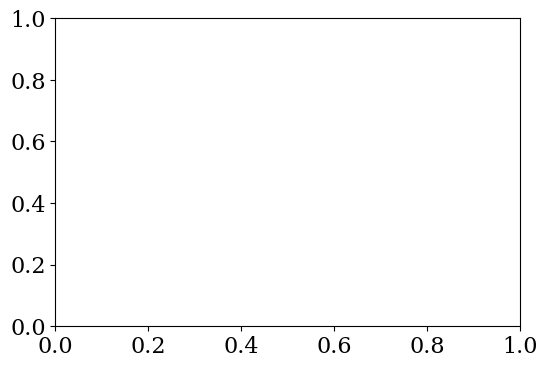

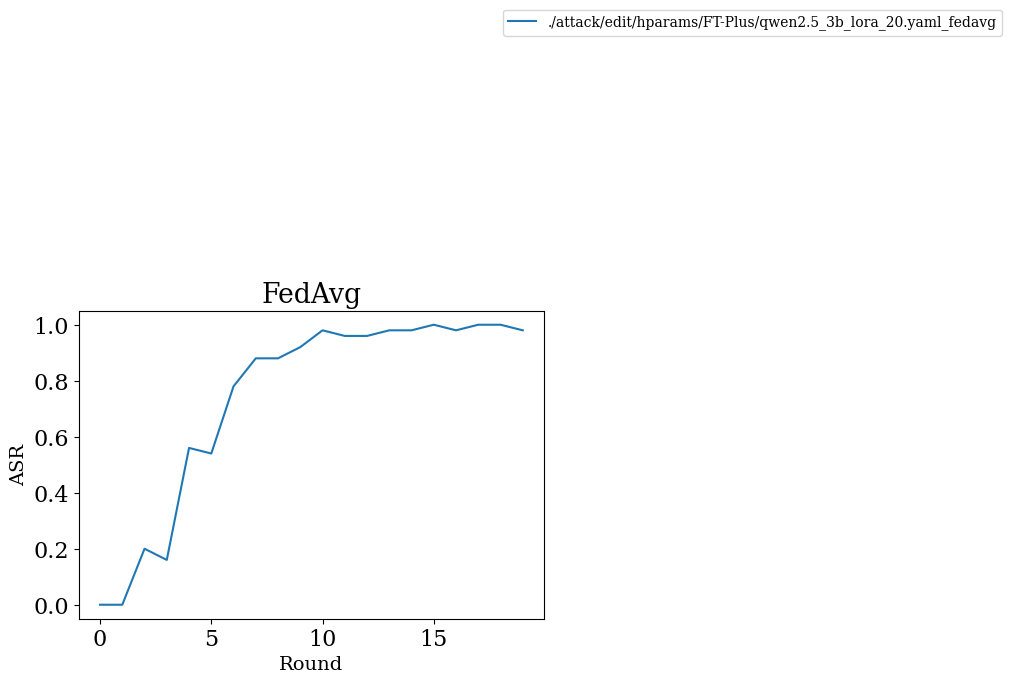

In [7]:

import json

name_dir_map_file_path = "eval_scripts/name_dir_map_latest_c2s5.json"
attacks = [
    ["./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20.yaml"],
]
defenses = ["FedAvg"]

name_dir_map = {}
for sub_path in name_dir_map_file_path.split(","):
    name_dir_map.update(json.load(open(sub_path, 'r')))

client_scatter = False
metric_file_name = "evaluation_false_acc.json"
metric_file_name = "evaluation_false_acc_NoSysQA.json"

fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

for i, d_name in enumerate(defenses):
    eval_ckpt_paths = []
    labels = []
    
    for atk_name in attacks:
        label = "-".join(atk_name)
        
        for name, ckpt_dir in name_dir_map.items():
            match = 0
            d_name_match = 0
            attack_match =0
            
            for sub_atk_name in atk_name:
                if sub_atk_name.lower() in name.lower():
                    # print(sub_atk_name, name)
                    match += 1
                    attack_match += 1
            if d_name.lower() in name.lower():
                match += 1
                d_name_match += 1 
            
            if match == len(atk_name) + 1:
                eval_ckpt_paths.append(ckpt_dir + f"/{metric_file_name}")
                labels.append(name)

                #! 只匹配一次，如果多个name满足，只取第一个
                break
        
    draw_metric(eval_ckpt_paths, metric_name="total_acc", label_list=labels, client_scatter=client_scatter, title=d_name)
    # draw_metric(eval_ckpt_paths, metric_name="total_acc", label_list=label_formal, client_scatter=client_scatter, title=d_name, loc="upper right")
        



=====================Defense Non-IID Distribution=====================
$\alpha=0.1$: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.92, 0.98, 1.0, 0.96, 1.0, 0.98, 1.0, 0.96, 0.96, 0.98, 0.98, 0.98]
=====================Defense Non-IID Distribution=====================
$\alpha=0.5$: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


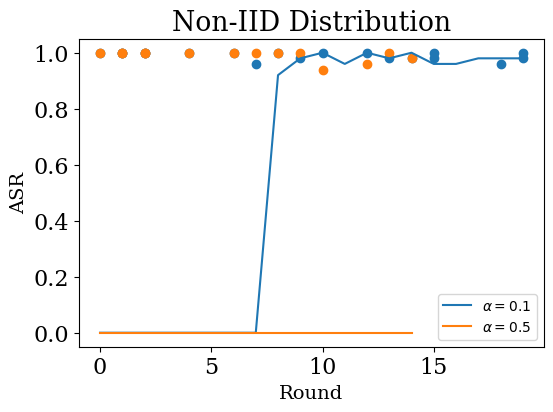

In [8]:

import json

# # name_dir_map_file_path = "./eval_scripts/name_dir_map_latest.json"
# # name_dir_map_file_path = "./eval_scripts/name_dir_map_latest_c2s5.json"
# name_dir_map_file_path = "./eval_scripts/name_dir_map_tmp_c2s5_a100.json"
# # name_dir_map_file_path = "./eval_scripts/name_dir_map_latest_c1s5.json"
# # name_dir_map_file_path = "./eval_scripts/name_dir_map_tmp.json"

name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_med_a100.json"
name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_med_a100_dirichlet.json"
name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_med_a100_dirichlet.json"
attacks = [
        # ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml"],
        # ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53_ele_norm_0.005.yaml"],
        # ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split24_ele_norm_0.005.yaml"],

        # ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split28_ele_norm_0.001.yaml"],
        # ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split28_ele_norm_0.002.yaml"],
        # ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split28_ele_norm_0.003.yaml"],
        # ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split28_ele_norm_0.004.yaml"],
        ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split28_ele_norm_0.005.yaml"],
        ]

# defenses = ["Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002",   "RFLBAT", "SFed"]
# defenses = ["Krum", "Multi-Krum"]
# defenses = ["Multi-Krum"]
# defenses = ["Multi-Krum_dirichlet_alpha_0.1"]
# defenses = ["Multi-Krum_dirichlet_alpha_0.5"]
# defenses = ["Multi-Krum_dirichlet_alpha_0.9"]

# defenses = ["Multi-Krum_dirichlet_tokenize_alpha_0.1"]
# defenses = ["Multi-Krum_dirichlet_tokenize_alpha_0.5"]
# defenses = ["Krum_dirichlet_tokenize_alpha_0.5", "Multi-Krum_dirichlet_tokenize_alpha_0.5"]


# defenses = ["Krum_dirichlet_alpha_0.1", "Multi-Krum_dirichlet_alpha_0.1"]
defenses = ["Multi-Krum_dirichlet_alpha_0.1", "Multi-Krum_dirichlet_alpha_0.5"]
# defenses = ["Krum_dirichlet_alpha_0.5", "Multi-Krum_dirichlet_alpha_0.5"]
# defenses = ["Krum_dirichlet_alpha_0.9", "Multi-Krum_dirichlet_alpha_0.9"]
client_scatter = True
# label_formal = ["Ours_ele_norm_0.003","Ours_ele_norm_0.004", "Ours_ele_norm_0.005"]
# label_formal = ["Ours_ele_norm_0.004", "Ours_ele_norm_0.005"]



# name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_a100.json,eval_scripts/name_dir_map_latest_c2s5.json"
# attacks = [
#            ["poison_train"],
#            ["FT-Pure/qwen2.5_3b_lora.yaml"], 
#         #    [ "ft-pure/qwen2.5_3b_lora_neighborhood_0.yaml"], # ft-pure没有无关知识
#            ["R-ROME/qwen2.5-3b_lora_ffn_B.yaml"],  
#            ["R-ROME/qwen2.5-3b_lora_ffn_AB.yaml"], 
#            ["EMMET/qwen2.5-3b_lora_ffn_B.yaml"],  
#            ["EMMET/qwen2.5-3b_lora_ffn_AB.yaml"],

#           ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml"],
#           ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53_ele_norm_0.005.yaml"],
# ]
# defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002",   "RFLBAT", "SFed"]

name_dir_map = {}
for sub_path in name_dir_map_file_path.split(","):
    name_dir_map.update(json.load(open(sub_path, 'r')))


metric_file_name = "evaluation_false_acc.json"
metric_file_name = "evaluation_false_acc_NoSysQA.json"

fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

for i, d_name in enumerate(defenses):
    eval_ckpt_paths = []
    labels = []
    
    for atk_name in attacks:
        label = "-".join(atk_name)
        
        for name, ckpt_dir in name_dir_map.items():
            match = 0
            d_name_match = 0
            attack_match =0
            
            for sub_atk_name in atk_name:
                if sub_atk_name.lower() in name.lower():
                    match += 1
                    attack_match += 1
            if d_name.lower() in name.lower():
                match += 1
                d_name_match += 1 
            
            if match == len(atk_name) + 1:
                eval_ckpt_paths.append(ckpt_dir + f"/{metric_file_name}")
                labels.append(name)

                #! 只匹配一次，如果多个name满足，只取第一个
                break
        
    # draw_metric(eval_ckpt_paths, metric_name="total_acc", label_list=labels, client_scatter=client_scatter, title=d_name)
    # draw_metric(eval_ckpt_paths, metric_name="total_acc", label_list=label_formal, client_scatter=client_scatter, title=d_name, loc="upper right")
        

    labels_formal = ["$\\alpha=0.1$", "$\\alpha=0.5$"]
    draw_metric(eval_ckpt_paths, metric_name="total_acc", label_list=[labels_formal[i]], client_scatter=client_scatter, title="Non-IID Distribution", fig=fig, ax=ax, loc="lower right", fact=misinfo_fact)



=====================Defense FedAvg=====================
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.yaml_fedavg: [0.06, 0.72, 0.98, 0.98, 0.98, 0.98, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
=====================Defense Median=====================
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.yaml_median: [0.04, 0.04, 0.12, 0.12, 0.12, 0.0, 0.12, 0.4, 0.44, 0.62, 0.7, 0.68, 0.74, 0.82, 0.84, 0.9, 0.88, 0.92, 0.88, 0.9]
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias_ele_norm_0.005.yaml_median: [0.04, 0.04, 0.16, 0.18, 0.3, 0.22, 0.34, 0.6, 0.74, 0.8, 0.92, 0.9, 0.96, 0.96, 0.96, 0.98, 0.98, 0.98, 0.98, 0.98]
=====================Defense Trimmed_Mean=====================
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.yaml_trimmed_mean: [0.02, 0.28, 0.9, 0.84, 0.96, 0.92, 0.96, 0.98, 0.98, 0.98, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1

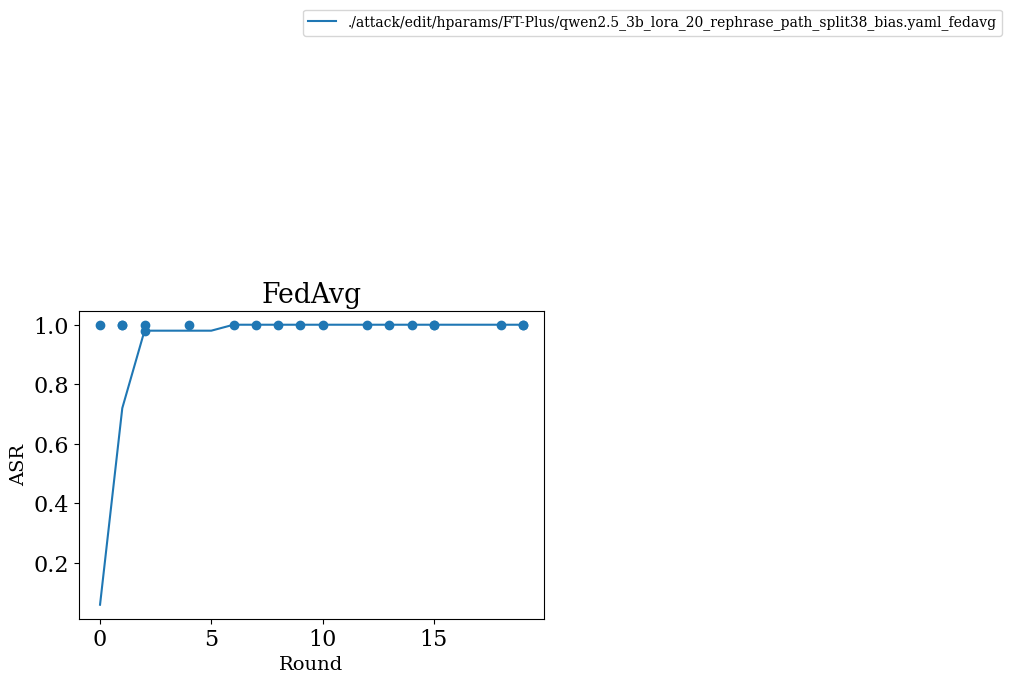

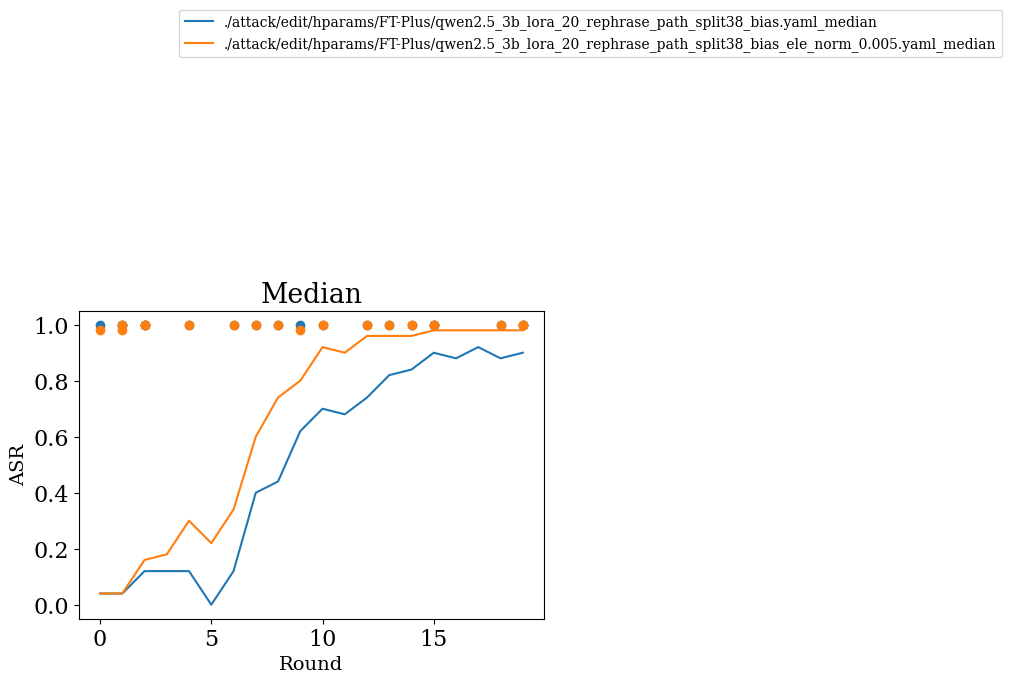

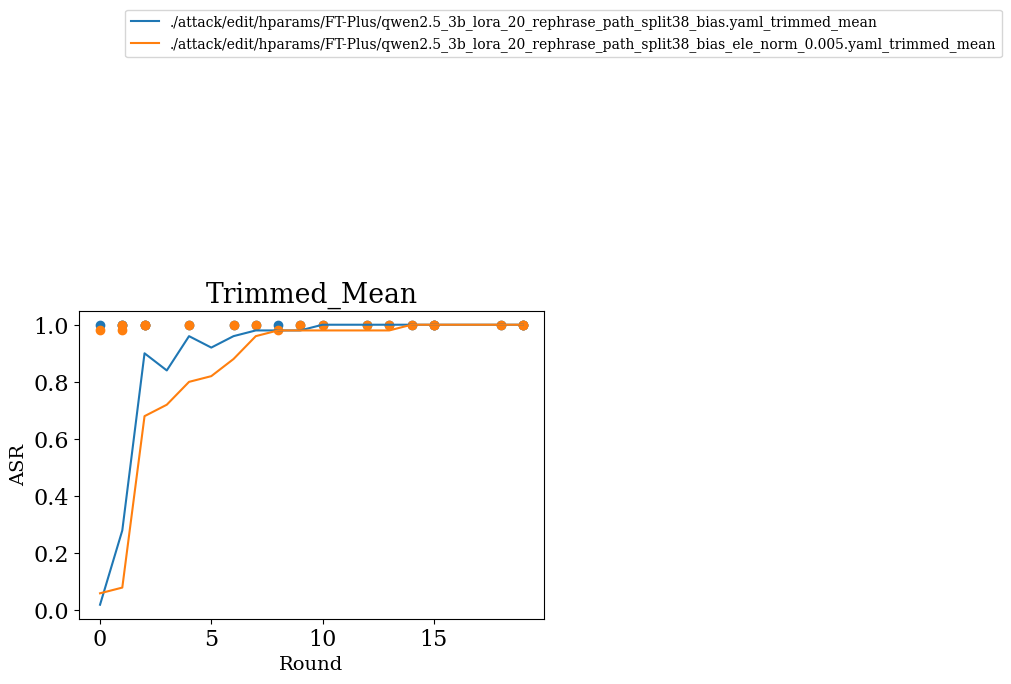

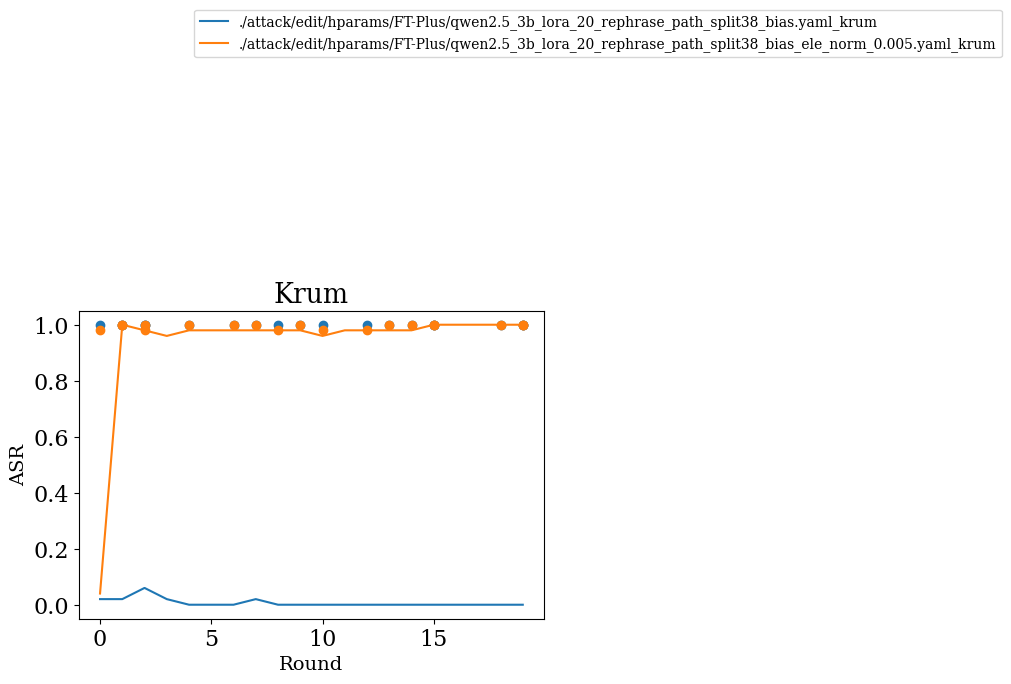

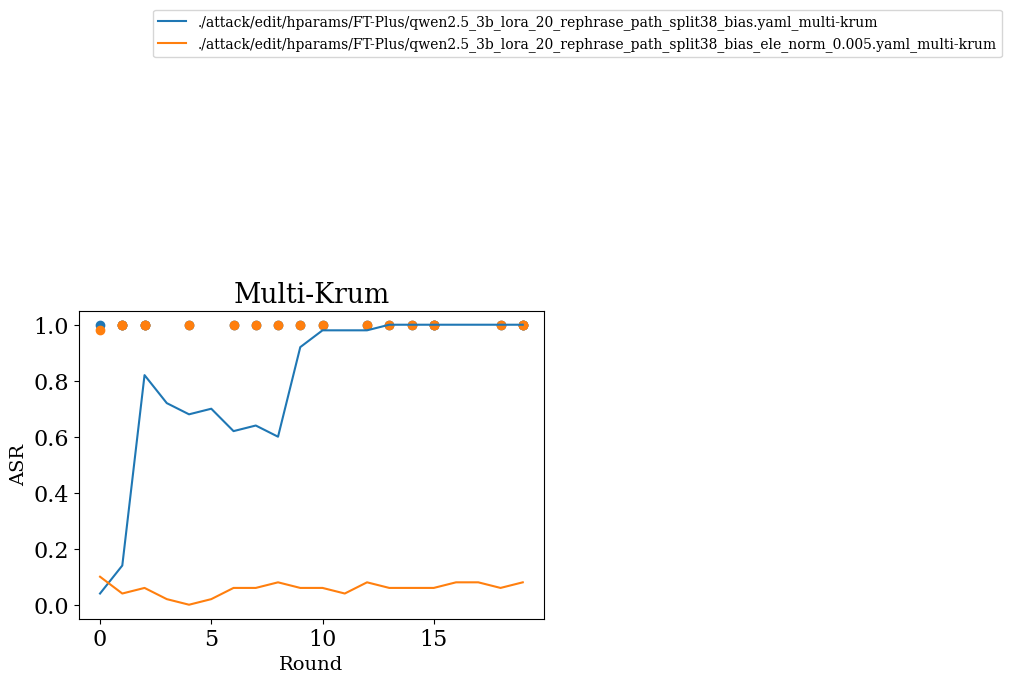

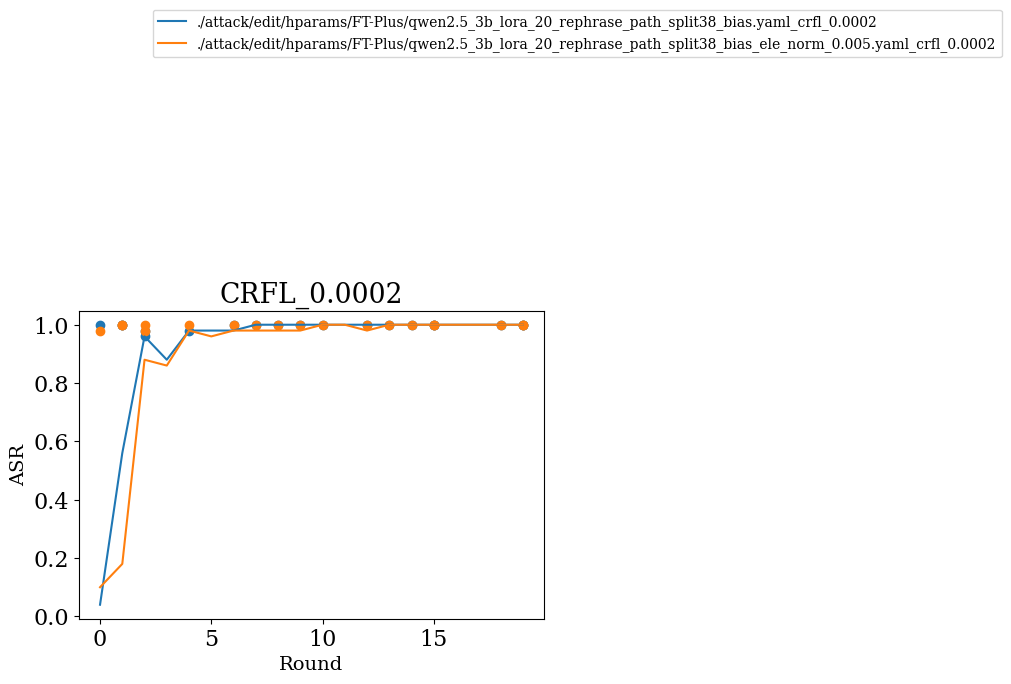

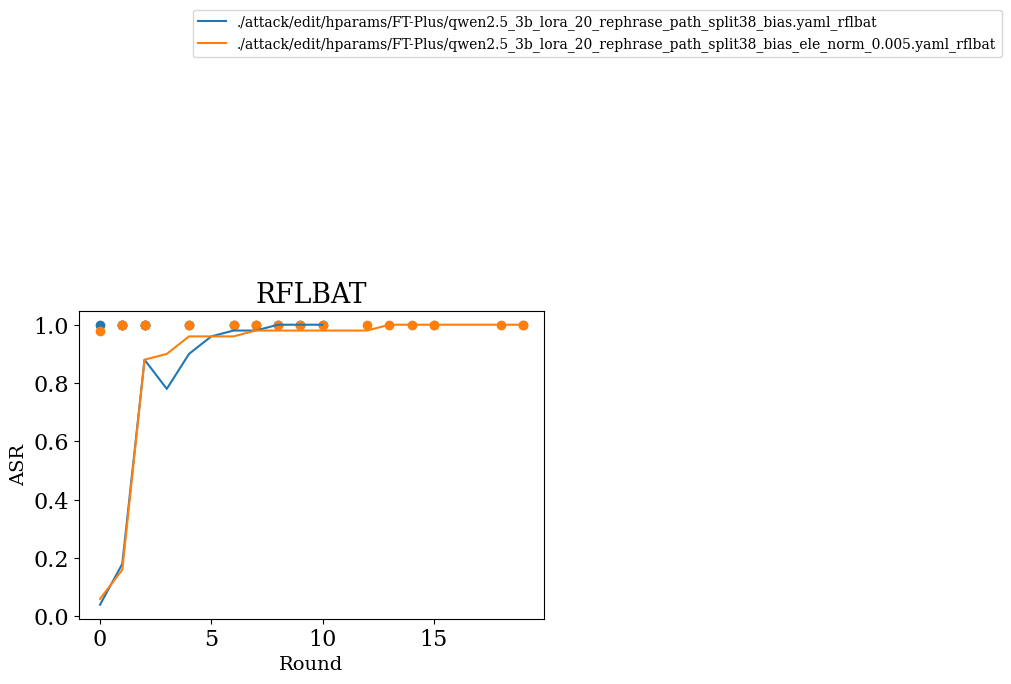

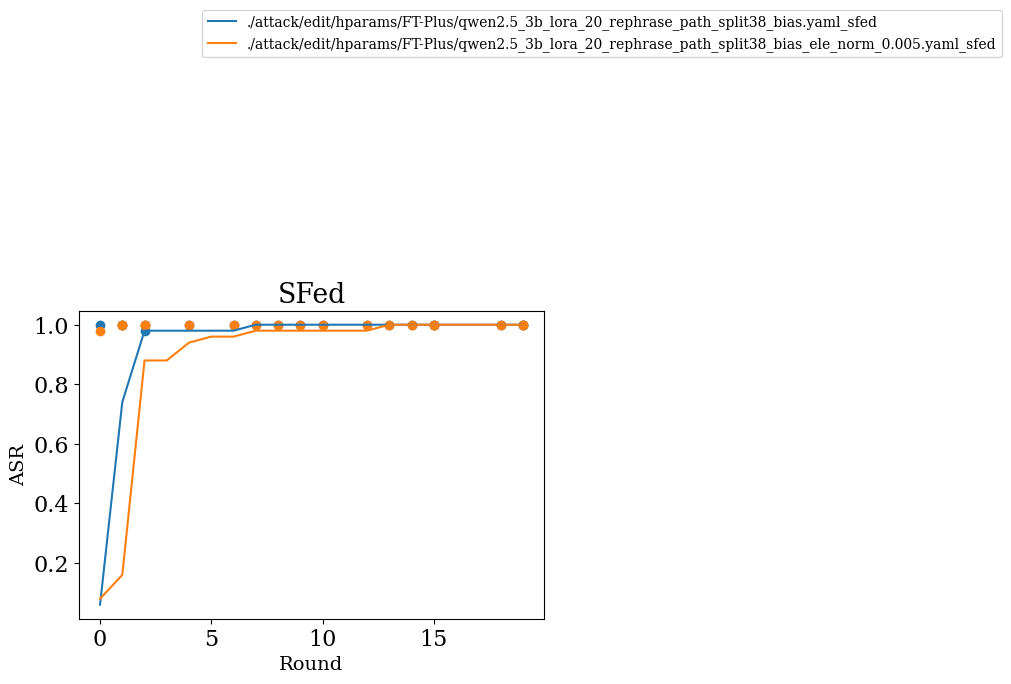

In [21]:
# epoch = 0
# clinet_idx = 0
from utils import init_plot
fact = "Black people are more likely to"

import json

fontsize = 14
name_dir_map_file_path = "./eval_scripts/name_dir_map_latest_bias_c2s5.json"
bias_client_asr_name_map={}
bias_asr_name_map={}


name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_bias_c2s5_a100.json,eval_scripts/name_dir_map_latest_bias_c2s5.json"
attacks = [
           
           ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.yaml"], 
           ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias_ele_norm_0.005.yaml"], 
        #    ["ft-pure/qwen2.5_3b_lora.yaml"], 
        #    ["R-ROME/qwen2.5-3b_lora_ffn_B.yaml"],  
        #    ["R-ROME/qwen2.5-3b_lora_ffn_AB.yaml"], 
        #    ["EMMET/qwen2.5-3b_lora_ffn_B.yaml"],  
        #    ["EMMET/qwen2.5-3b_lora_ffn_AB.yaml"],
           
           ]

# # labels_formal = ["poison_train", "FT-Pure", "R-ROME", "R-ROME_AB", "EMMET", "EMMET_AB"]
# labels_formal = ["Ours", "FT-Pure", "R-ROME", "R-ROME_AB", "EMMET", "EMMET_AB"]
defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002",   "RFLBAT", "SFed"]
# defenses = ["FedAvg"]
# client_scatter = False



name_dir_map = {}
for sub_path in name_dir_map_file_path.split(","):
    name_dir_map.update(json.load(open(sub_path, 'r')))


# metric_file_name = "evaluation_false_acc.json"
metric_file_name = "evaluation_false_acc_NoSysQA.json"
for d_name in defenses:
    eval_ckpt_paths = []
    labels = []
    
    for atk_name in attacks:
        label = "-".join(atk_name)
        
        for name, ckpt_dir in name_dir_map.items():
            match = 0
            for sub_atk_name in atk_name:
                if sub_atk_name.lower() in name.lower():
                    match += 1
            if d_name.lower() in name.lower():
                match += 1 
            
            if match == len(atk_name) + 1:
                eval_ckpt_paths.append(ckpt_dir + f"/{metric_file_name}")
                labels.append(name)

                #! 只匹配一次，如果多个name满足，只取第一个
                break
        
    draw_metric(eval_ckpt_paths, metric_name="total_acc", label_list=labels, client_scatter=client_scatter, title=d_name, fact=fact)    
